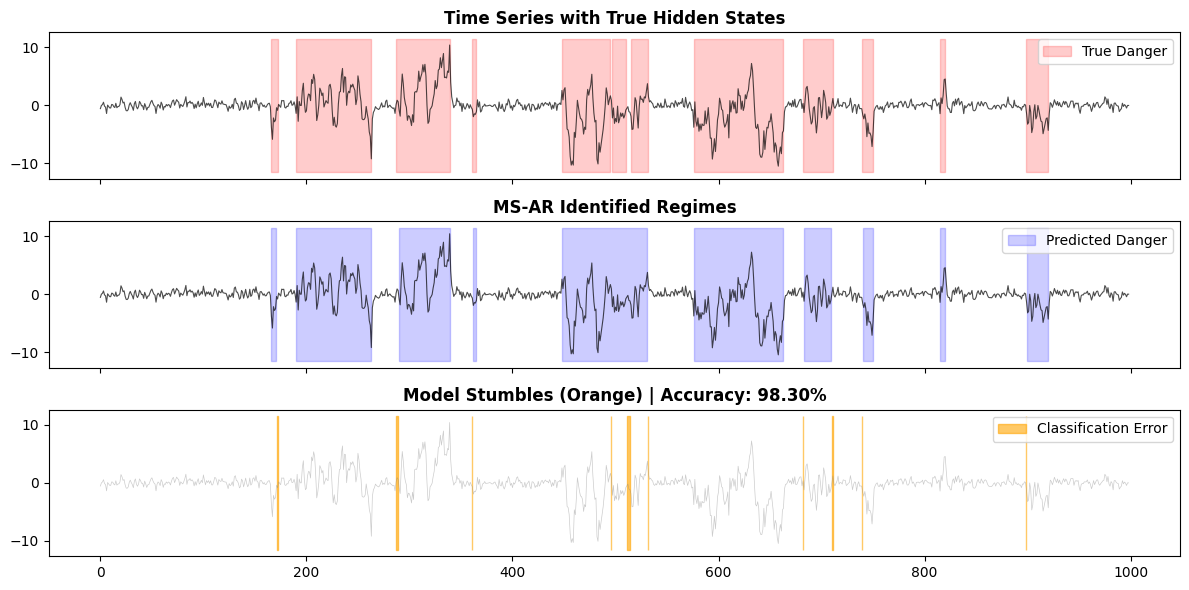

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.regime_switching.markov_autoregression import MarkovAutoregression
from sklearn.metrics import accuracy_score

np.random.seed(42)
N = 1000

# 1. Simulate Regimes
# P[i, j] = Prob(next state = j | current state = i)
P = np.array([[0.98, 0.02], [0.05, 0.95]])
phi = np.array([0.3, 0.9])    # State 0: Quick mean reversion; State 1: Random walk
sigma = np.array([0.5, 2.0])  # State 0: Low vol; State 1: High vol

states = np.zeros(N, dtype=int)
y = np.zeros(N)

for t in range(1, N):
    states[t] = np.random.choice([0, 1], p=P[states[t-1]])
    s = states[t]
    y[t] = phi[s] * y[t-1] + sigma[s] * np.random.randn()

# 2. Fit MS-AR
model = MarkovAutoregression(y, k_regimes=2, order=1, switching_ar=True, switching_variance=True)
res = model.fit(search_reps=20, disp=False)

# 3. Process Predictions
# Match labels by variance to handle label switching
params = dict(zip(res.model.param_names, res.params))
danger_state = 1 if params['sigma2[1]'] > params['sigma2[0]'] else 0

probs = res.smoothed_marginal_probabilities
if isinstance(probs, pd.DataFrame): probs = probs.values
pred_states = (probs[:, danger_state] > 0.5).astype(int)

# Align true states (AR(1) drops first observation)
true_states = states[1:]
y_plot = y[1:]
is_correct = (pred_states == true_states)

# 4. Plotting the Comparison
fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)

# Panel 1: True Regimes
axes[0].plot(y_plot, color='black', lw=0.8, alpha=0.7)
axes[0].fill_between(range(len(y_plot)), axes[0].get_ylim()[0], axes[0].get_ylim()[1], 
                    where=(true_states==1), color='red', alpha=0.2, label='True Danger')
axes[0].set_title('Time Series with True Hidden States', fontweight='bold')

# Panel 2: Predicted Regimes
axes[1].plot(y_plot, color='black', lw=0.8, alpha=0.7)
axes[1].fill_between(range(len(y_plot)), axes[1].get_ylim()[0], axes[1].get_ylim()[1], 
                    where=(pred_states==1), color='blue', alpha=0.2, label='Predicted Danger')
axes[1].set_title('MS-AR Identified Regimes', fontweight='bold')

# Panel 3: Classification Errors
axes[2].plot(y_plot, color='gray', lw=0.5, alpha=0.4)
axes[2].fill_between(range(len(y_plot)), axes[2].get_ylim()[0], axes[2].get_ylim()[1], 
                    where=(~is_correct), color='orange', alpha=0.6, label='Classification Error')
axes[2].set_title(f'Model Stumbles (Orange) | Accuracy: {accuracy_score(true_states, pred_states):.2%}', fontweight='bold')

for ax in axes: ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('../plots/eda/true-and-hidden-states.pdf')
plt.show()